Recover convective power and magnetic energy from dynamo simulation 
=====
***

In [2]:
using Plots
using Distributions
using StatsBase
using DelimitedFiles
using Interpolations

Constants

In [4]:
kyr = 1.0e3
mT = 1.0e-3
TW = 1.0e12;

pscale = 1.0/0.98; # convert power density to total power in W 
tscale = 459630;  # years
sectoyear = 365.25 * 24 * 60 * 60

# geometry 
b = 3.48e6
c = 1.22e6
L = b - c
V = 4 * pi * (b^3 - c^3)/3

# physical properties
ρ = 1.1e4
ν = L^2 / (tscale * sectoyear)
μ = 4 * π * 1.0e-7
Ω_true = 0.7292e-4;
vscale = ν/L

# dimensionless constants
Ek = 3e-7  # Ekman
Pm = 0.4;
η = ν/Pm
Ω = ν / (Ek * L^2)
bscale = sqrt(ρ * μ * η * Ω_true)

0.0009419912763591244

Read total convective power

In [6]:
data = readdlm("power2.dat")
tp = (data[:,1].-data[1,1]) * tscale/kyr;
p = data[:,2] /(pscale * TW);    # in TW

# remove redundant elements
deleteat!(tp,88105:88453)
deleteat!(p,88105:88453)

ndata_in = length(tp)

152710

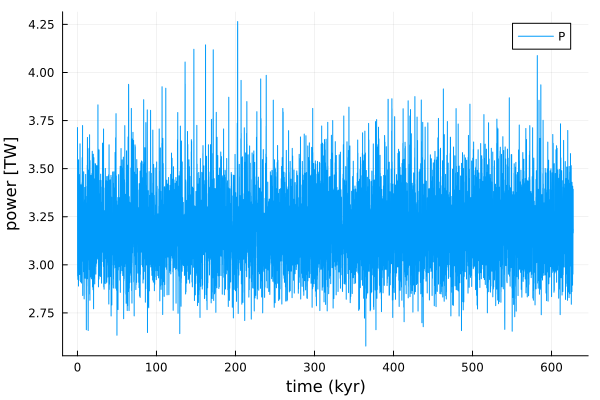

In [7]:
idecimate = 20;
plot(tp[1:idecimate:end],p[1:idecimate:end],
    xlabel="time (kyr)",
    ylabel="power [TW]",label="P")

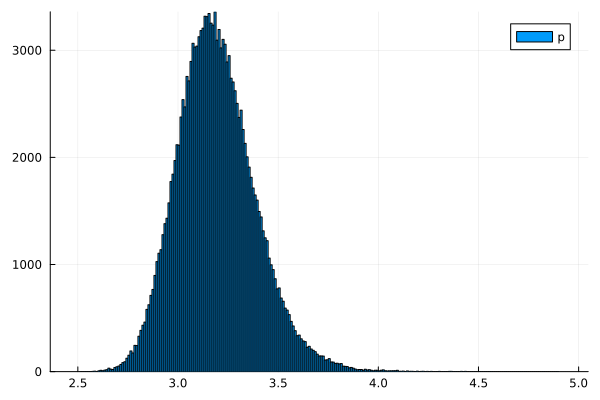

In [8]:
histogram(p,label="p")

In [9]:
println("mean = ",mean(p)," TW",'\n',"std = ",std(p)," TW",'\n',"skewness = ",skewness(p))

mean = 3.192803551682453 TW
std = 0.19477727609355708 TW
skewness = 0.5134523177291044


In [10]:
# Interpolate onto a uniform time grid
dt =  tp[end]/ndata_in;
tpinp = (0.0 : dt : tp[end]);
nodes = (tp,);
itp = interpolate(nodes,p,Gridded(Linear()));
pinp = itp(tpinp);
ndata = length(tpinp)

152711

Evaluate autocorrelation of uncorrected power

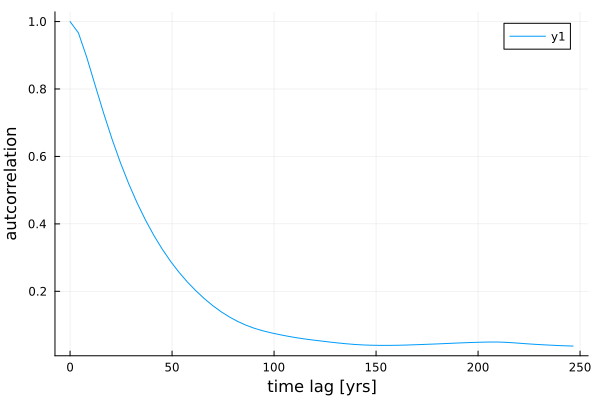

In [12]:
lag = (0 : 60)
c = autocor(pinp,lag,demean=true)
plot(lag * dt * kyr, c,
    xlabel="time lag [yrs]",
    ylabel="autcorrelation")

Compute correlation time

In [14]:
tau = 0.0;

for i = 1 : length(lag)-1
    tau = tau + 0.5*(c[i]+c[i+1])*dt
end
taup = lag[findfirst(y->y < exp(-1.0),c)]

print(" Integrated correlation time = " ,tau," kyr")
print("\n Point correlation time = ",taup*dt," kyr")

 Integrated correlation time = 0.04483632432180279 kyr
 Point correlation time = 0.04109801387402996 kyr

Read magnetic energy

In [16]:
data = readdlm("e_mag2.dat")
tb = (data[:,1].-data[1,1]) * tscale / kyr;
b2 = 2 * data[:,2] * Ek * Pm * bscale^2;

# remove redundant elements
deleteat!(tb,88105:88453)
deleteat!(b2,88105:88453)

m = b2 / (ρ * μ);
ndata_in = length(tb)

152710

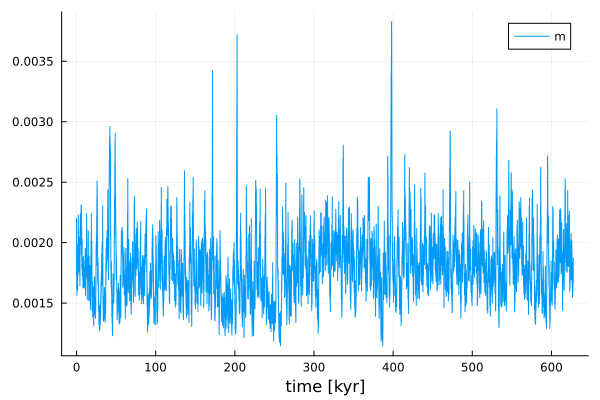

In [17]:
idecimate = 20;
plot(tb,m,label="m",xlabel="time [kyr]")

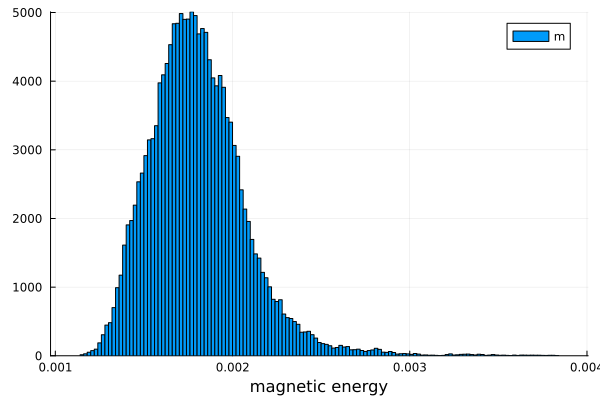

In [18]:
histogram(m,label="m",xlabel="magnetic energy")

In [19]:
println("mean = ",mean(m),'\n',
    "std = ",std(m),'\n',
    "skewness = ",skewness(m))

mean = 0.0018050837024003175
std = 0.0002751045758657193
skewness = 1.1830333968803364


In [20]:
# Interpolate onto a uniform time grid
dt =  tb[end]/ndata_in; 
tbinp = (0.0 : dt : tb[end]);
nodes = (tb,);
itp = interpolate(nodes,m,Gridded(Linear()));
m_inp = itp(tbinp);
ndata = length(tbinp)

152711

Read kinetic energy

In [22]:
data = readdlm("e_kin2.dat")
tv = (data[:,1].-data[1,1]) * tscale/kyr;
v2 = 2*data[:,2];
ke_nd = data[:,2];

# remove redundant elements
deleteat!(tv,88105:88453)
deleteat!(v2,88105:88453)

v = sqrt.(v2) * vscale
ndata_in = length(tv)
println("Overturn time = ",(L/mean(v))/sectoyear," yr")

Overturn time = 105.49179164054819 yr


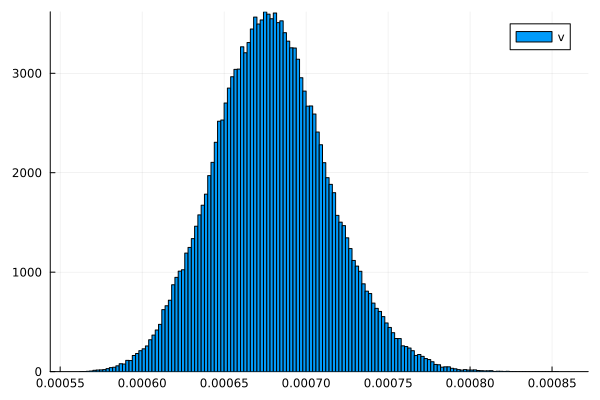

In [23]:
histogram(v,label="v")

In [24]:
# Interpolate onto a uniform time grid
dt =  tv[end]/ndata_in; 
tvinp = (0.0 : dt : tv[end]);
nodes = (tv,);
itp = interpolate(nodes,v,Gridded(Linear()));
vinp = itp(tvinp);
ndata = length(tvinp)

152711